# Smart Manufacturing Resource Efficiency Dataset Analysis

This notebook analyses manufacturing resource efficiency data to investigate sustainable manufacturing performance through energy consumption, recycled material usage, production output, and defect rate.

In [24]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Load Dataset + Structure + Data Types + Descriptive Statistics
df = pd.read_csv("smart_manufacturing_dataset.csv")

print("First Five Records:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

First Five Records:


,Timestamp,Machine ID,Material Category,Material Name,Quantity Used (kg),Recycled Material (%),Energy Consumption (kWh),Production Output (Units),Defect Rate (%)
0,2025-05-01 08:00:00,M002,Raw Material,Polypropylene,86.73,0.0,96.74,204,3.38
1,2025-05-01 08:05:00,M009,Raw Material,Cotton,54.77,0.0,91.24,338,2.53
2,2025-05-01 08:10:00,M001,Hazardous Material,Lead-Based Alloy,157.40,0.0,164.16,529,1.10
3,2025-05-01 08:15:00,M010,Process Additive,Industrial Oil,163.82,0.0,99.16,532,1.70
4,2025-05-01 08:20:00,M003,Intermediate Material,Plastic Resin,65.33,0.0,125.59,467,4.24



Dataset Shape:
(10000, 9)

Column Names:
['Timestamp', 'Machine ID', 'Material Category', 'Material Name', 'Quantity Used (kg)', 'Recycled Material (%)', 'Energy Consumption (kWh)', 'Production Output (Units)', 'Defect Rate (%)']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  10000 non-null  str    
 1   Machine ID                 10000 non-null  str    
 2   Material Category          10000 non-null  str    
 3   Material Name              10000 non-null  str    
 4   Quantity Used (kg)         10000 non-null  float64
 5   Recycled Material (%)      10000 non-null  float64
 6   Energy Consumption (kWh)   10000 non-null  float64
 7   Production Output (Units)  10000 non-null  int64  
 8   Defect Rate (%)            10000 non-null  float64
dtypes: float64(4), int64(1), str(4

,Quantity Used (kg),Recycled Material (%),Energy Consumption (kWh),Production Output (Units),Defect Rate (%)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,124.534008,4.060385,140.111901,553.481500,2.526966
std,43.136723,10.908877,34.540921,260.877808,1.442364
min,50.010000,0.000000,80.010000,100.000000,0.000000
25%,87.215000,0.000000,110.647500,327.000000,1.290000
50%,124.250000,0.000000,140.315000,554.000000,2.540000
75%,161.752500,0.000000,169.877500,780.000000,3.780000
max,200.000000,49.960000,200.000000,1000.000000,5.000000


In [39]:
# Remove unnecessary feature from previous analysis
df = df.drop(columns=["Energy Efficiency (Units/kWh)"], errors="ignore")

print("Dataset Shape:", df.shape)
print("Column Names:", df.columns.tolist())

Dataset Shape: (10000, 9)
Column Names: ['Timestamp', 'Machine ID', 'Material Category', 'Material Name', 'Quantity Used (kg)', 'Recycled Material (%)', 'Energy Consumption (kWh)', 'Production Output (Units)', 'Defect Rate (%)']


In [26]:
# Timestamp Transformation
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Start Date:", df["Timestamp"].min())
print("End Date:", df["Timestamp"].max())
print("Data Type:", df["Timestamp"].dtype)

Start Date: 2025-05-01 08:00:00
End Date: 2025-06-05 01:15:00
Data Type: datetime64[us]


In [27]:
# Missing Values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values:
Timestamp                    0
Machine ID                   0
Material Category            0
Material Name                0
Quantity Used (kg)           0
Recycled Material (%)        0
Energy Consumption (kWh)     0
Production Output (Units)    0
Defect Rate (%)              0
dtype: int64

Total Missing Values: 0


In [28]:
# Duplicate Records
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [29]:
# Data Consistency
print("Negative Quantity Used:",
      (df["Quantity Used (kg)"] < 0).sum())

print("Negative Energy Consumption:",
      (df["Energy Consumption (kWh)"] < 0).sum())

print("Negative Production Output:",
      (df["Production Output (Units)"] < 0).sum())

print("Recycled Material (%) outside 0-100:",
      ((df["Recycled Material (%)"] < 0) |
       (df["Recycled Material (%)"] > 100)).sum())

print("Defect Rate (%) outside 0-100:",
      ((df["Defect Rate (%)"] < 0) |
       (df["Defect Rate (%)"] > 100)).sum())

Negative Quantity Used: 0
Negative Energy Consumption: 0
Negative Production Output: 0
Recycled Material (%) outside 0-100: 0
Defect Rate (%) outside 0-100: 0


In [30]:
# Material Category Distribution
print("Number of Material Categories:",
      df["Material Category"].nunique())

print("\nMaterial Categories:")
print(df["Material Category"].unique())

print("\nRecords per Material Category:")
print(df["Material Category"].value_counts())

Number of Material Categories: 6

Material Categories:
<ArrowStringArray>
[         'Raw Material',    'Hazardous Material',      'Process Additive',
 'Intermediate Material',     'Finished Material',     'Recycled Material']
Length: 6, dtype: str

Records per Material Category:
Material Category
Raw Material             1758
Finished Material        1714
Intermediate Material    1681
Hazardous Material       1639
Recycled Material        1620
Process Additive         1588
Name: count, dtype: int64


In [31]:
# Feature Engineering: Energy Efficiency

df["Energy Efficiency (Units/kWh)"] = (
    df["Production Output (Units)"] /
    df["Energy Consumption (kWh)"]
)

print("Energy Efficiency Summary:")
display(
    df["Energy Efficiency (Units/kWh)"].describe().round(2)
)

print("\nFirst Five Records:")
display(
    df[
        [
            "Production Output (Units)",
            "Energy Consumption (kWh)",
            "Energy Efficiency (Units/kWh)"
        ]
    ].head()
)

Energy Efficiency Summary:


count    10000.00
mean         4.22
std          2.35
min          0.51
25%          2.36
50%          3.95
75%          5.65
max         12.29
Name: Energy Efficiency (Units/kWh), dtype: float64


First Five Records:


,Production Output (Units),Energy Consumption (kWh),Energy Efficiency (Units/kWh)
0,204,96.74,2.108745
1,338,91.24,3.704516
2,529,164.16,3.222466
3,532,99.16,5.365067
4,467,125.59,3.718449


In [32]:
# Check Energy Efficiency for invalid values

print("Missing Energy Efficiency:")
print(df["Energy Efficiency (Units/kWh)"].isnull().sum())

print("\nInfinite Energy Efficiency:")
print(np.isinf(df["Energy Efficiency (Units/kWh)"]).sum())

print("\nNon-positive Energy Efficiency:")
print((df["Energy Efficiency (Units/kWh)"] <= 0).sum())

Missing Energy Efficiency:
0

Infinite Energy Efficiency:
0

Non-positive Energy Efficiency:
0


In [33]:
# Check categorical variables

categorical_columns = [
    "Machine ID",
    "Material Category",
    "Material Name"
]

for column in categorical_columns:
    print(f"\n{column}")
    print("Number of unique values:", df[column].nunique())
    print("Missing values:", df[column].isnull().sum())
    print("Unique values:")
    print(df[column].unique())


Machine ID
Number of unique values: 10
Missing values: 0
Unique values:
<ArrowStringArray>
['M002', 'M009', 'M001', 'M010', 'M003', 'M005', 'M004', 'M006', 'M008',
 'M007']
Length: 10, dtype: str

Material Category
Number of unique values: 6
Missing values: 0
Unique values:
<ArrowStringArray>
[         'Raw Material',    'Hazardous Material',      'Process Additive',
 'Intermediate Material',     'Finished Material',     'Recycled Material']
Length: 6, dtype: str

Material Name
Number of unique values: 17
Missing values: 0
Unique values:
<ArrowStringArray>
[       'Polypropylene',               'Cotton',     'Lead-Based Alloy',
       'Industrial Oil',        'Plastic Resin',            'Packaging',
        'Circuit Board', 'Reprocessed Plastics',    'Machine Component',
             'Aluminum',             'Textiles',          'Sheet Metal',
              'Solvent',          'Scrap Steel',                'Steel',
              'Coolant',             'Catalyst']
Length: 17, dtype: str

In [34]:
# RQ2 Data Preparation
# Check variables required for correlation analysis

rq2_columns = [
    "Energy Consumption (kWh)",
    "Production Output (Units)"
]

print("RQ2 Variables:")
print(df[rq2_columns].describe().round(2))

print("\nMissing Values:")
print(df[rq2_columns].isnull().sum())

print("\nNon-positive Values:")

for column in rq2_columns:
    print(
        f"{column}:",
        (df[column] <= 0).sum()
    )

RQ2 Variables:
       Energy Consumption (kWh)  Production Output (Units)
count                  10000.00                   10000.00
mean                     140.11                     553.48
std                       34.54                     260.88
min                       80.01                     100.00
25%                      110.65                     327.00
50%                      140.32                     554.00
75%                      169.88                     780.00
max                      200.00                    1000.00

Missing Values:
Energy Consumption (kWh)     0
Production Output (Units)    0
dtype: int64

Non-positive Values:
Energy Consumption (kWh): 0
Production Output (Units): 0


In [35]:
# RQ3 Data Preparation
# Check variables required for material category comparison

rq3_columns = [
    "Material Category",
    "Recycled Material (%)",
    "Production Output (Units)",
    "Defect Rate (%)"
]

print("RQ3 Variables:")
display(df[rq3_columns].describe(include="all"))

print("\nMissing Values:")
print(df[rq3_columns].isnull().sum())

print("\nNumber of Records per Material Category:")
print(df["Material Category"].value_counts())

RQ3 Variables:


,Material Category,Recycled Material (%),Production Output (Units),Defect Rate (%)
count,10000,10000.000000,10000.000000,10000.000000
unique,6,NaN,NaN,NaN
top,Raw Material,NaN,NaN,NaN
freq,1758,NaN,NaN,NaN
mean,NaN,4.060385,553.481500,2.526966
std,NaN,10.908877,260.877808,1.442364
min,NaN,0.000000,100.000000,0.000000
25%,NaN,0.000000,327.000000,1.290000
50%,NaN,0.000000,554.000000,2.540000
75%,NaN,0.000000,780.000000,3.780000



Missing Values:
Material Category            0
Recycled Material (%)        0
Production Output (Units)    0
Defect Rate (%)              0
dtype: int64

Number of Records per Material Category:
Material Category
Raw Material             1758
Finished Material        1714
Intermediate Material    1681
Hazardous Material       1639
Recycled Material        1620
Process Additive         1588
Name: count, dtype: int64


In [40]:
# RQ1 Data Preparation Summary

preparation_summary = {
    "Total Records": len(df),
    "Total Variables": df.shape[1],
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Records": df.duplicated().sum(),
    "Invalid Numerical Values": (
        (df["Quantity Used (kg)"] < 0).sum()
        + (df["Energy Consumption (kWh)"] < 0).sum()
        + (df["Production Output (Units)"] < 0).sum()
        + ((df["Recycled Material (%)"] < 0) |
           (df["Recycled Material (%)"] > 100)).sum()
        + ((df["Defect Rate (%)"] < 0) |
           (df["Defect Rate (%)"] > 100)).sum()
    ),
    "Material Categories": df["Material Category"].nunique(),
    "Machine IDs": df["Machine ID"].nunique(),
    "Material Types": df["Material Name"].nunique(),
    "Timestamp Data Type": str(df["Timestamp"].dtype)
}

print("RQ1 Data Preparation Summary:")
for key, value in preparation_summary.items():
    print(f"{key}: {value}")

RQ1 Data Preparation Summary:
Total Records: 10000
Total Variables: 9
Missing Values: 0
Duplicate Records: 0
Invalid Numerical Values: 0
Material Categories: 6
Machine IDs: 10
Material Types: 17
Timestamp Data Type: datetime64[us]


In [41]:
# RQ1 Data Preparation Decision

print("========== RQ1: Data Preparation Decision ==========")

print("\n1. Missing Values:")
if df.isnull().sum().sum() == 0:
    print("No missing values found. No imputation or row removal is required.")
else:
    print("Missing values found. Further treatment is required.")

print("\n2. Duplicate Records:")
if df.duplicated().sum() == 0:
    print("No duplicate records found. No duplicate removal is required.")
else:
    print("Duplicate records found. Duplicate removal is required.")

print("\n3. Numerical Data Consistency:")
invalid_values = (
    (df["Quantity Used (kg)"] < 0).sum()
    + (df["Energy Consumption (kWh)"] < 0).sum()
    + (df["Production Output (Units)"] < 0).sum()
    + ((df["Recycled Material (%)"] < 0) |
       (df["Recycled Material (%)"] > 100)).sum()
    + ((df["Defect Rate (%)"] < 0) |
       (df["Defect Rate (%)"] > 100)).sum()
)

if invalid_values == 0:
    print("No invalid numerical values found. No correction is required.")
else:
    print("Invalid numerical values found. Further treatment is required.")

print("\n4. Timestamp:")
print("Timestamp has been converted from string to datetime format.")

print("\n5. Categorical Variables:")
print("Machine ID, Material Category, and Material Name were checked for")
print("unique values and missing values.")

========== RQ1: Data Preparation Decision ==========

1. Missing Values:
No missing values found. No imputation or row removal is required.

2. Duplicate Records:
No duplicate records found. No duplicate removal is required.

3. Numerical Data Consistency:
No invalid numerical values found. No correction is required.

4. Timestamp:
Timestamp has been converted from string to datetime format.

5. Categorical Variables:
Machine ID, Material Category, and Material Name were checked for
unique values and missing values.


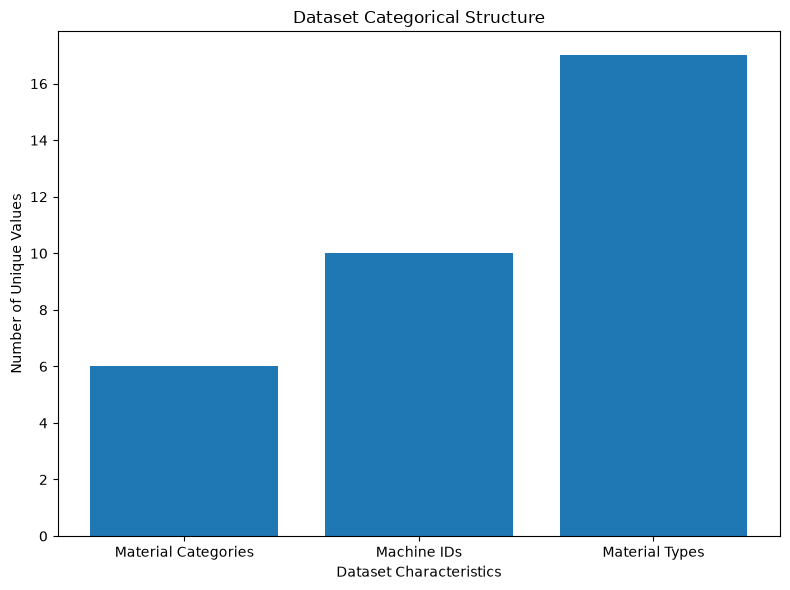

In [55]:
# RQ1 Visualisation – Dataset Categorical Structure

structure_data = {
    "Material Categories": df["Material Category"].nunique(),
    "Machine IDs": df["Machine ID"].nunique(),
    "Material Types": df["Material Name"].nunique()
}

fig = plt.figure(figsize=(8, 6))
ax = plt.axes()

ax.bar(
    structure_data.keys(),
    structure_data.values()
)

ax.set_xlabel("Dataset Characteristics")
ax.set_ylabel("Number of Unique Values")

ax.set_title(
    "Dataset Categorical Structure"
)

plt.tight_layout()

fig.savefig(
    "rq1_dataset_categorical_structure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# RQ2: Energy Consumption and Production Output

rq2_variables = df[[
    "Energy Consumption (kWh)",
    "Production Output (Units)"
]]

print("RQ2 Variables:")
display(rq2_variables.describe())

print("\nMissing Values:")
print(rq2_variables.isnull().sum())

print("\nNon-positive Values:")
print("Energy Consumption (kWh):",
      (rq2_variables["Energy Consumption (kWh)"] <= 0).sum())

print("Production Output (Units):",
      (rq2_variables["Production Output (Units)"] <= 0).sum())

RQ2 Variables:


,Energy Consumption (kWh),Production Output (Units)
count,10000.000000,10000.000000
mean,140.111901,553.481500
std,34.540921,260.877808
min,80.010000,100.000000
25%,110.647500,327.000000
50%,140.315000,554.000000
75%,169.877500,780.000000
max,200.000000,1000.000000



Missing Values:
Energy Consumption (kWh)     0
Production Output (Units)    0
dtype: int64

Non-positive Values:
Energy Consumption (kWh): 0
Production Output (Units): 0


In [43]:
# RQ2: Pearson Correlation Analysis

correlation = df["Energy Consumption (kWh)"].corr(
    df["Production Output (Units)"]
)

print("Pearson Correlation:")
print("Correlation coefficient:", round(correlation, 3))

Pearson Correlation:
Correlation coefficient: -0.002


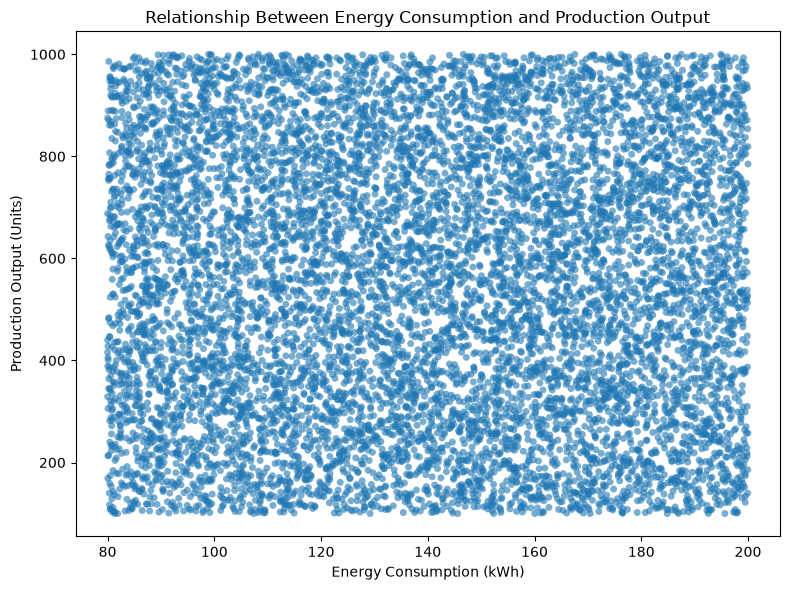

In [45]:
# RQ2: Scatter Plot

fig = plt.figure(figsize=(8, 6))
ax = plt.axes()

ax.scatter(
    df["Energy Consumption (kWh)"],
    df["Production Output (Units)"],
    s=25,
    alpha=0.6,
    edgecolors="none"
)

ax.set_xlabel("Energy Consumption (kWh)")
ax.set_ylabel("Production Output (Units)")

ax.set_title(
    "Relationship Between Energy Consumption and Production Output"
)

plt.tight_layout()

fig.savefig(
    "rq2_energy_output_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
print("========== RQ2 Visualisation Data ==========")

print("Number of observations:", len(df))

print("\nEnergy Consumption Range:")
print(
    df["Energy Consumption (kWh)"].min(),
    "to",
    df["Energy Consumption (kWh)"].max()
)

print("\nProduction Output Range:")
print(
    df["Production Output (Units)"].min(),
    "to",
    df["Production Output (Units)"].max()
)

print("\nPearson Correlation:")
print(
    df["Energy Consumption (kWh)"]
    .corr(df["Production Output (Units)"])
)

========== RQ2 Visualisation Data ==========
Number of observations: 10000

Energy Consumption Range:
80.01 to 200.0

Production Output Range:
100 to 1000

Pearson Correlation:
-0.0016605595880965693


In [52]:
# ============================================================
# RQ3 – Grouped Descriptive Statistics
# ============================================================

rq3_summary = df.groupby("Material Category").agg(
    Records=("Material Category", "size"),
    Average_Recycled_Material=("Recycled Material (%)", "mean"),
    Average_Production_Output=("Production Output (Units)", "mean"),
    Average_Defect_Rate=("Defect Rate (%)", "mean")
).round(2)

print("========== RQ3 Grouped Descriptive Statistics ==========")
display(rq3_summary)

========== RQ3 Grouped Descriptive Statistics ==========


,Records,Average_Recycled_Material,Average_Production_Output,Average_Defect_Rate
Material Category,,,,
Finished Material,1714,0.00,546.34,2.52
Hazardous Material,1639,0.00,558.93,2.52
Intermediate Material,1681,0.00,556.53,2.52
Process Additive,1588,0.00,560.98,2.53
Raw Material,1758,0.00,551.20,2.54
Recycled Material,1620,25.06,547.49,2.52


In [53]:
# ============================================================
# RQ3 – Visualisation Data
# ============================================================

print("========== RQ3 Visualisation Data ==========")

print("\nNumber of Material Categories:")
print(df["Material Category"].nunique())

print("\nMaterial Category Summary:")
display(
    df.groupby("Material Category")[
        [
            "Recycled Material (%)",
            "Production Output (Units)",
            "Defect Rate (%)"
        ]
    ].mean().round(2)
)

========== RQ3 Visualisation Data ==========

Number of Material Categories:
6

Material Category Summary:


,Recycled Material (%),Production Output (Units),Defect Rate (%)
Material Category,,,
Finished Material,0.00,546.34,2.52
Hazardous Material,0.00,558.93,2.52
Intermediate Material,0.00,556.53,2.52
Process Additive,0.00,560.98,2.53
Raw Material,0.00,551.20,2.54
Recycled Material,25.06,547.49,2.52


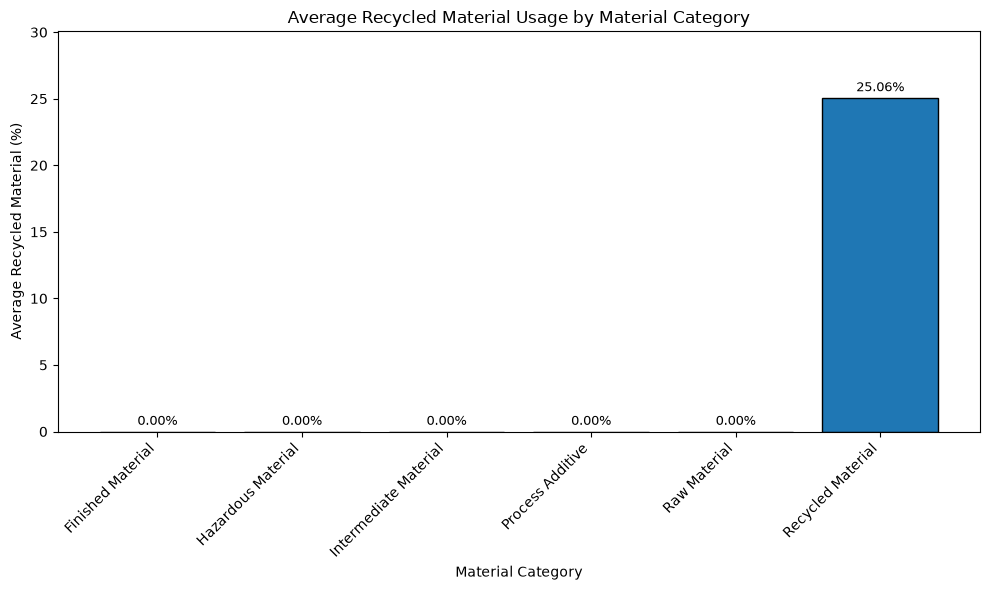

In [66]:
# ============================================================
# Figure 3(a) – Average Recycled Material Usage
# ============================================================

rq3_recycled = df.groupby("Material Category")["Recycled Material (%)"].mean()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes()

bars = ax.bar(
    rq3_recycled.index,
    rq3_recycled.values,
    edgecolor="black"
)

ax.set_xlabel("Material Category")
ax.set_ylabel("Average Recycled Material (%)")
ax.set_title("Average Recycled Material Usage by Material Category")

ax.set_xticks(range(len(rq3_recycled.index)))
ax.set_xticklabels(
    rq3_recycled.index,
    rotation=45,
    ha="right"
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=9
    )

ax.set_ylim(0, max(rq3_recycled.values) + 5)

plt.tight_layout()

fig.savefig(
    "rq3a_recycled_material_usage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

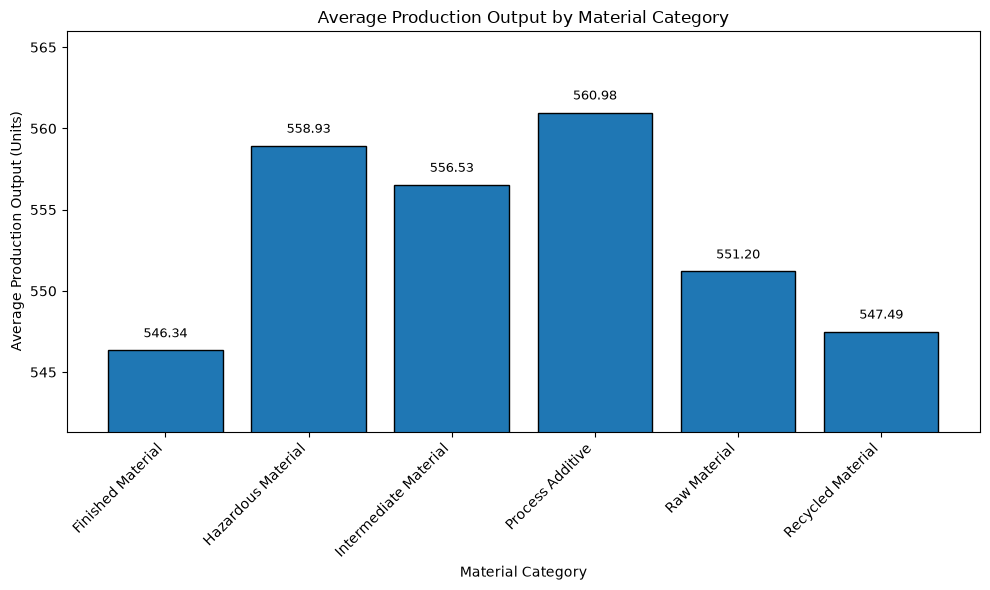

In [69]:
# ============================================================
# Figure 3(b) – Average Production Output
# ============================================================

rq3_output = df.groupby("Material Category")["Production Output (Units)"].mean()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes()

bars = ax.bar(
    rq3_output.index,
    rq3_output.values,
    edgecolor="black"
)

ax.set_xlabel("Material Category")
ax.set_ylabel("Average Production Output (Units)")
ax.set_title("Average Production Output by Material Category")

ax.set_xticks(range(len(rq3_output.index)))
ax.set_xticklabels(
    rq3_output.index,
    rotation=45,
    ha="right"
)

# Focus the y-axis on the actual range of the averages
ax.set_ylim(
    rq3_output.min() - 5,
    rq3_output.max() + 5
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

fig.savefig(
    "rq3b_production_output.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

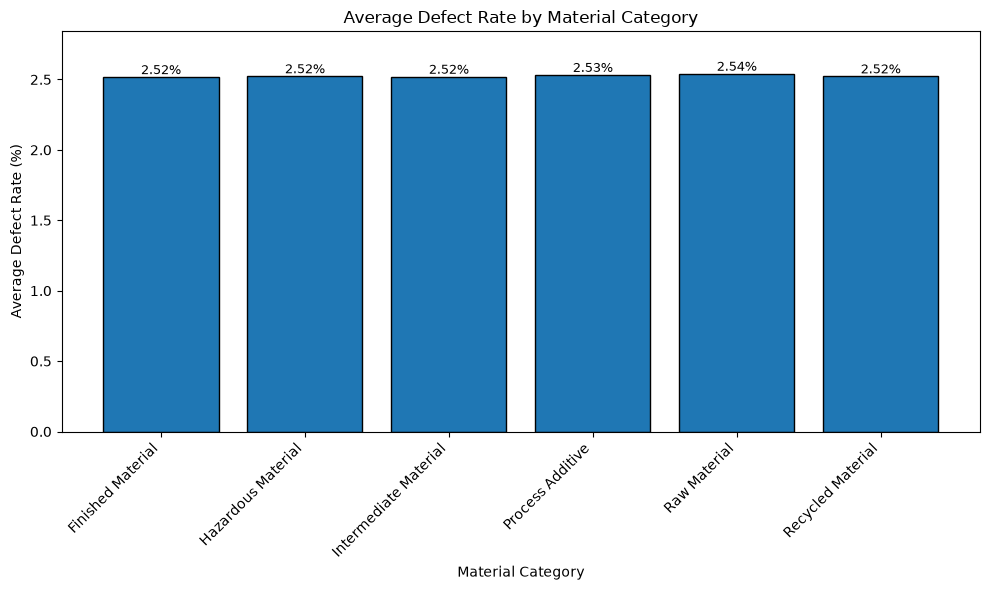

In [71]:
# ============================================================
# Figure 3(c) – Average Defect Rate
# ============================================================

rq3_defect = df.groupby("Material Category")["Defect Rate (%)"].mean()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes()

bars = ax.bar(
    rq3_defect.index,
    rq3_defect.values,
    edgecolor="black"
)

ax.set_xlabel("Material Category")
ax.set_ylabel("Average Defect Rate (%)")
ax.set_title("Average Defect Rate by Material Category")

ax.set_xticks(range(len(rq3_defect.index)))
ax.set_xticklabels(
    rq3_defect.index,
    rotation=45,
    ha="right"
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}%",
        ha="center",
        fontsize=9
    )

ax.set_ylim(0, max(rq3_defect.values) + 0.3)

plt.tight_layout()

fig.savefig(
    "rq3c_defect_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()